In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import warnings
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import seaborn as sns
import cogwheel.posterior
from cogwheel import utils, gw_utils, gw_plotting, plotting
import cogwheel.data

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
# from generate_injection_params import generate_injection_parameters
import helpers
from injections import create_injection

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"
warnings.simplefilter("ignore", RuntimeWarning)

#### compute $\Delta\ln\mathcal L\equiv\ln\mathcal L_\mathrm{II}^\mathrm{max}(\psi) - \ln\mathcal L_\mathrm{I}^\mathrm{max}(\psi\pm\pi/4)$. does this match our formula?

We want
$$
\mathrm{max}_D\ln\mathcal L(d^U|\vec\theta) - \mathrm{max}_D\ln\mathcal L(d^L|\vec\theta')
$$
with $d^L$ the lensed data, $d^U$ the unlensed data, $\vec\theta$ the injected parameters, and $\vec\theta'=\vec\theta(\psi\pm\pi/4)$ the imposter parameters.

In [3]:
def compute_mismatches(post, ed_u, noise=False, plot=True, verbose=True):

    approximant = ed_u.injection['approximant']
    injected_par_dic = ed_u.injection['par_dic']

    if noise == False:
        # reinstantiate with zero noise
        ed_u_0 = ed_u.reinstantiate(strain=np.zeros_like(ed_u.strain))
        ed_u_0.inject_signal(par_dic=injected_par_dic, approximant=approximant)
    else:
        # otherwise just keep the event data the same
        ed_u_0 = ed_u

    # likelihood
    like_u_0 = post.likelihood
    like_u_0.event_data = ed_u_0
    like_u_0._set_summary()
    like_u_0.asd_drift = None

    # Type II lens
    ed_0 = ed_u_0.reinstantiate(strain=ed_u_0.strain * 1j)
    like_0 = deepcopy(like_u_0)
    like_0.event_data = ed_0
    like_0._set_summary()
    like_0.asd_drift = None

    # what's the likelihood of the unlensed event data given the injected parameters?
    maxlnlike_u = like_u_0.lnlike_fft(injected_par_dic)
    if verbose:
        print(f"max ln likelihood of the unlensed data given injected parameters is {maxlnlike_u:.1f}")

    # what's the likelihood of the lensed event data given the imposter parameters?
    shifts = [+np.pi/4, -np.pi/4]
    shift_strs = ['+ pi/4', '- pi/4']
    maxlnlikes = []
    for shift_str, shift in zip(shift_strs, shifts):
        maxlnlike_imposter = like_0.lnlike_fft(injected_par_dic | dict(psi=injected_par_dic['psi'] + shift))
        if verbose:
            print(f"max ln likelihood of the lensed data given unlensed imposter (psi -> psi {shift_str}) is {maxlnlike_imposter:.1f}")
        maxlnlikes.append(maxlnlike_imposter)
    # take the max
    idx_max = np.argmax(maxlnlikes)
    maxlnlike_imposter = maxlnlikes[idx_max]
    shift_best = shifts[idx_max]
    if verbose:
        print(f"taking psi {shift_strs[idx_max]} as the best imposter")

    # maximize the likelihood over distance given the unlensed imposter
    maxD_res = helpers.max_over_distance(like_0, injected_par_dic, shift_best)
    maxlnlike_imposter_dL = -maxD_res['fun']
    if verbose:
        print(f"max ln likelihood given imposter, maximized over distance, is {maxlnlike_imposter_dL:.1f} at {maxD_res['x']:.1f} Mpc")

    rhosq = np.sum(ed_0.injection['h_h'])
    maxlnlike_diff = maxlnlike_u - maxlnlike_imposter_dL
    lnlike_mismatch = (maxlnlike_u - maxlnlike_imposter_dL) / rhosq
    if verbose:
        print(f"max lnlike difference (mismatch) = {maxlnlike_diff:.1f} ({lnlike_mismatch:.3f})")

    if plot:
        shift_strs_latex = [r'$+ \pi/4$', r'$- \pi/4$']
        # compare the lensed and unlensed waveforms
        kwargs = dict(trng=(-.1, 0.), alpha=0.6, lw=3, data_plot_kwargs=dict(c='k', lw=1.5, ls='--', alpha=1.))
        like_0.plot_whitened_wf(injected_par_dic, c='royalblue', figsize=(10,6), zorder=100, plot_data=True, **kwargs)
        labels = ['Lensed data', 'Unlensed waveform (injected pars)']
        custom_lines = [Line2D([0], [0], **kwargs['data_plot_kwargs']),
                        Line2D([0], [0], c='royalblue', alpha=kwargs['alpha'], lw=kwargs['lw'])]
        # like.plot_whitened_wf(like.par_dic_0, c='seagreen', fig=plt.gcf(), **kwargs)
        c = 'crimson'
        for shift, shift_str in zip(shifts, shift_strs_latex):
            imposter_par_dic = injected_par_dic | dict(psi=injected_par_dic['psi'] + shift, d_luminosity=maxD_res['x'])
            alpha = 0.5 if shift == shift_best else 0.2
            lw = 3 if shift == shift_best else kwargs['lw']
            like_0.plot_whitened_wf(imposter_par_dic, c=c, fig=plt.gcf(), plot_data=False, **kwargs | dict(alpha=alpha, lw=lw))
            labels.append(r'Unlensed imposter ($\psi\rightarrow\psi$'f'{shift_str})')
            custom_lines.append(Line2D([0], [0], c=c, lw=kwargs['lw'], alpha=alpha))
        plt.gca().legend(custom_lines, labels, loc=4, fontsize=8)

    ## expected mismatch from formula ##
    # waveform (frequency domain) in each detector
    HH = helpers.compute_HH(like_0)

    # antenna response functions
    init_dict = ed_0.get_init_dict()
    fplus, fcross = gw_utils.fplus_fcross(init_dict['detector_names'],
                                            injected_par_dic['ra'], injected_par_dic['dec'],
                                            injected_par_dic['psi'], init_dict['tgps'])
    
    # then the expected ln Bayes
    mu = np.cos(injected_par_dic['iota'])
    formula_mismatch = helpers.expected_mismatch_with_HH(fplus, fcross, mu, HH)
    expected_diff = rhosq * formula_mismatch
    if verbose:
        print(f"expected difference (mismatch) from formula = {expected_diff:.2f} ({formula_mismatch:.3f})")

    return maxlnlike_diff, expected_diff, rhosq

In [4]:
# parameters to inject
pars_to_inject = {
    'm1' : 30., # Msun
    'm2' : 30., # Msun
    'd_luminosity' : 500.,  # Mpc
    'iota' : 0.,
    'ra' : 0.5, # fix the sky location for consistency
    'dec' : 0.5,    # rad
    's1z' : 0., # zero spin
    's2z' : 0.,
    's1x' : 0.,
    's1y' : 0.,
    's2x' : 0.,
    's2y' : 0.
}

### 1. face-on binary, zero-noise. does $\Delta\ln\mathcal L = 0$?

Setting reference from injection.


max ln likelihood of the unlensed data given injected parameters is 2187.4
max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is 2187.4
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -6562.1
taking psi + pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 2187.4 at 500.0 Mpc
max lnlike difference (mismatch) = -0.0 (-0.000)
expected difference (mismatch) from formula = nan (nan)


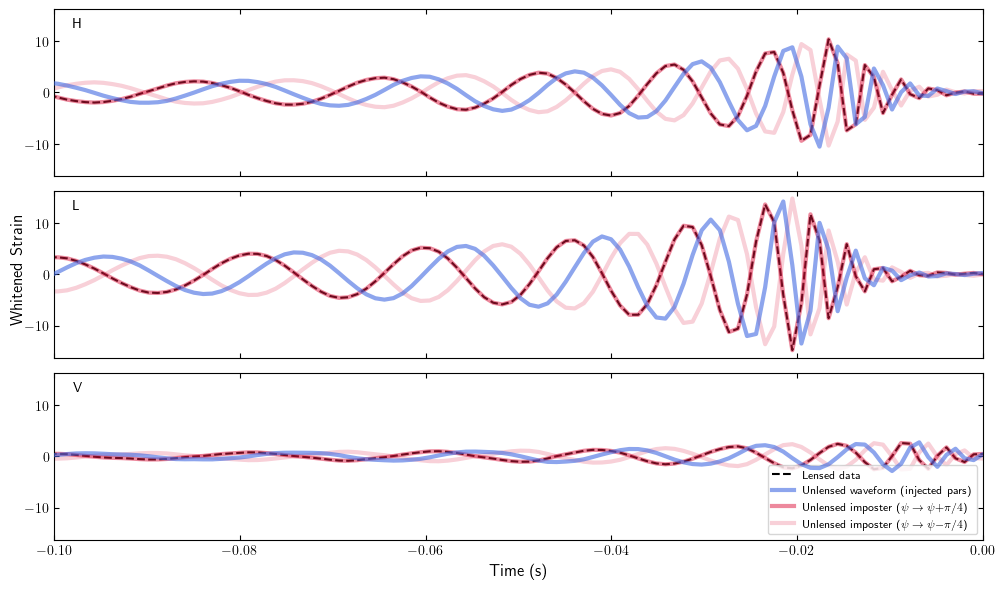

In [5]:
# injection parameters
iota = 0.
seed = 12
approximant = 'IMRPhenomXPHM'
ed_u = create_injection(pars_to_inject | dict(iota = iota), seed=seed, approximant=approximant)
# get the full injected parameter dictionary
injected_par_dic = ed_u.injection['par_dic']

# fast likelihood maximization to find the reference waveform
mchirp = gw_utils.m1m2_to_mchirp(pars_to_inject['m1'], pars_to_inject['m2'])
prior_class = 'IntrinsicLVCPrior'
post = cogwheel.posterior.Posterior.from_event(
    ed_u,
    mchirp,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': injected_par_dic['f_ref'],
        'time_range': (-0.1, 0.1)
    }
)
maxlnlike_diff, expected_diff, rhosq = compute_mismatches(post, ed_u)

### 2. edge-on binary, zero noise. does $\Delta\ln\mathcal L = 0.5$?

Setting reference from injection.


max ln likelihood of the unlensed data given injected parameters is 30.2
max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is -434.3
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -434.3
taking psi + pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 0.0 at 41903786.3 Mpc
max lnlike difference (mismatch) = 30.2 (0.500)
expected difference (mismatch) from formula = 30.23 (0.500)


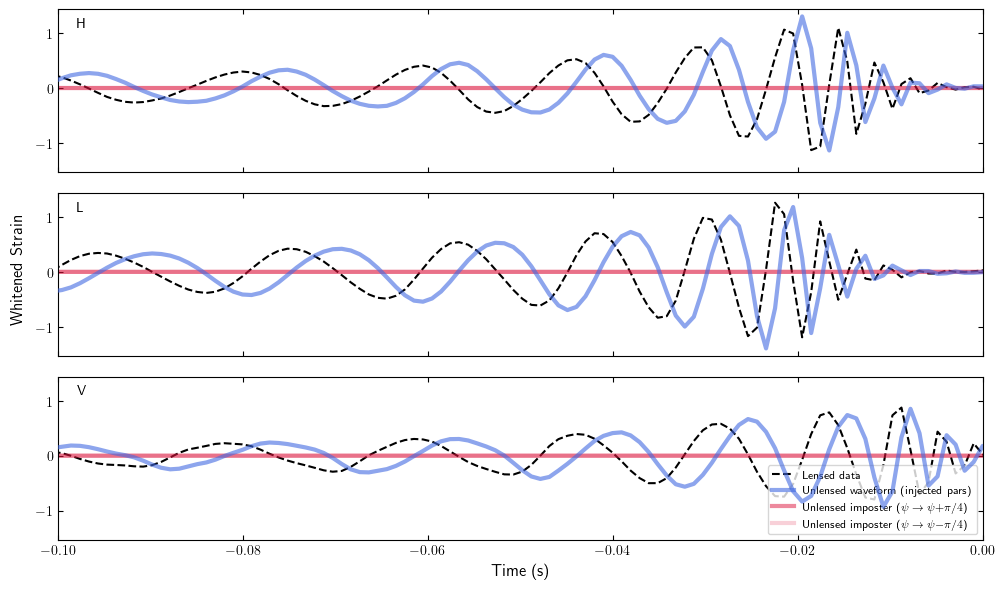

In [6]:
# injection parameters
iota = np.pi / 2
seed = 12
approximant = 'IMRPhenomXPHM'
ed_u = create_injection(pars_to_inject | dict(iota = iota), seed=seed, approximant=approximant)
# get the full injected parameter dictionary
injected_par_dic = ed_u.injection['par_dic']

# fast likelihood maximization to find the reference waveform
mchirp = gw_utils.m1m2_to_mchirp(pars_to_inject['m1'], pars_to_inject['m2'])
prior_class = 'IntrinsicLVCPrior'
post = cogwheel.posterior.Posterior.from_event(
    ed_u,
    mchirp,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': injected_par_dic['f_ref'],
        'time_range': (-0.1, 0.1)
    }
)
maxlnlike_diff, expected_diff, rhosq = compute_mismatches(post, ed_u)

### 3. $\iota=4\pi/9$, zero noise.

Setting reference from injection.


max ln likelihood of the unlensed data given injected parameters is 89.9
max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is -120.3
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -817.5
taking psi + pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 64.8 at 1345.2 Mpc
max lnlike difference (mismatch) = 25.1 (0.140)
expected difference (mismatch) from formula = 27.24 (0.151)


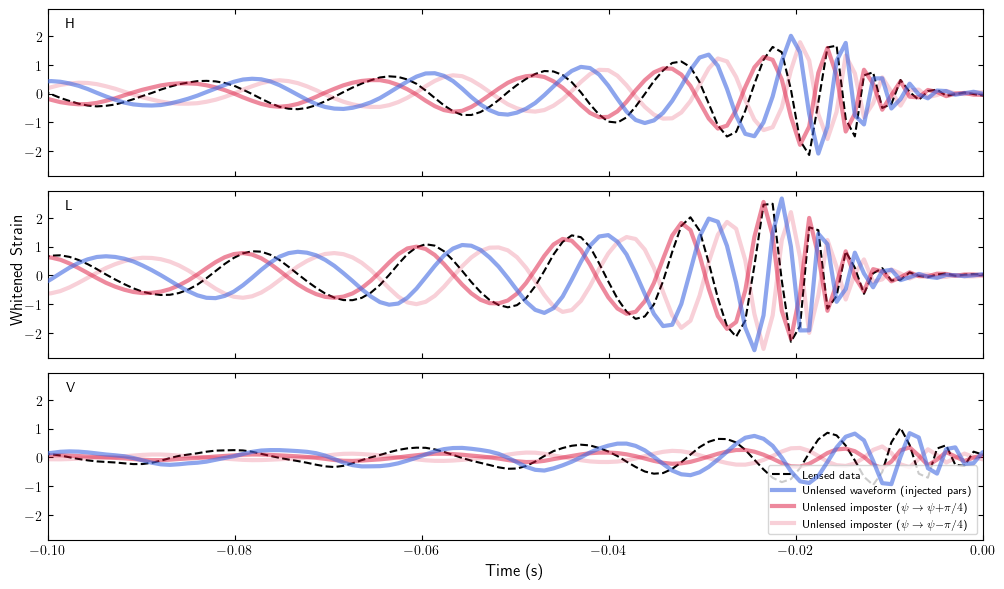

In [7]:
# injection parameters
iota = 4 * np.pi / 9
seed = 12
approximant = 'IMRPhenomXPHM'
ed_u = create_injection(pars_to_inject | dict(iota = iota), seed=seed, approximant=approximant)
# get the full injected parameter dictionary
injected_par_dic = ed_u.injection['par_dic']

# fast likelihood maximization to find the reference waveform
mchirp = gw_utils.m1m2_to_mchirp(pars_to_inject['m1'], pars_to_inject['m2'])
prior_class = 'IntrinsicLVCPrior'
post = cogwheel.posterior.Posterior.from_event(
    ed_u,
    mchirp,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': injected_par_dic['f_ref'],
        'time_range': (-0.1, 0.1)
    }
)
maxlnlike_diff, expected_diff, rhosq = compute_mismatches(post, ed_u)

### mismatch as a function of inclination

In [12]:
labels = [r'$f(\iota,\alpha,\delta,\psi,d_L,\langle H|H\rangle)$', r'$\Delta\ln\mathcal L/\rho^2$']

In [13]:
# do this for a range of inclinations
seed = 12
approximant = 'IMRPhenomXPHM'

iotas = np.arange(0., np.pi / 2 + 0.01, 0.05 * np.pi)

mchirp = gw_utils.m1m2_to_mchirp(pars_to_inject['m1'], pars_to_inject['m2'])

fn = 'mismatches_iota.npy'
if os.path.exists(fn):
    res = np.load(fn, allow_pickle=True).item()
    maxlnlike_diffs = res['maxlnlike_diffs']
    expected_diffs = res['expected_diffs']
    rhosqs = res['rhosqs']
else:
    maxlnlike_diffs = np.empty_like(iotas)
    expected_diffs = np.empty_like(iotas)
    rhosqs = np.empty_like(iotas)

    for i, iota in enumerate(iotas):
        print(f"iota = {iota / np.pi:.2f}π")

        ed_u = create_injection(pars_to_inject | dict(iota = iota), seed=seed, approximant=approximant)
        # get the full injected parameter dictionary
        injected_par_dic = ed_u.injection['par_dic']

        # fast likelihood maximization to find the reference waveform
        prior_class = 'IntrinsicLVCPrior'
        post = cogwheel.posterior.Posterior.from_event(
            ed_u,
            mchirp,
            approximant,
            prior_class,
            ref_wf_finder_kwargs={
                'f_ref': injected_par_dic['f_ref'],
                'time_range': (-0.1, 0.1)
            }
        )
        maxlnlike_diffs[i], expected_diffs[i], rhosqs[i] = compute_mismatches(post, ed_u, plot=False, verbose=False)
    res = {
        'pars_to_inject' : pars_to_inject,
        'iotas' : iotas,
        'maxlnlike_diffs' : maxlnlike_diffs,
        'expected_diffs' : expected_diffs,
        'rhosqs' : rhosqs
    }
    np.save(fn, res)

Text(0.5, 1.0, 'Type II lensed mismatch, zero noise realization:\nzero spin, $\\mathcal M=$ 26.12 $M_\\odot$, $q=$ 1, $d_L=$ 500 Mpc, $(\\alpha,\\delta)=$ (0.5,0.5)')

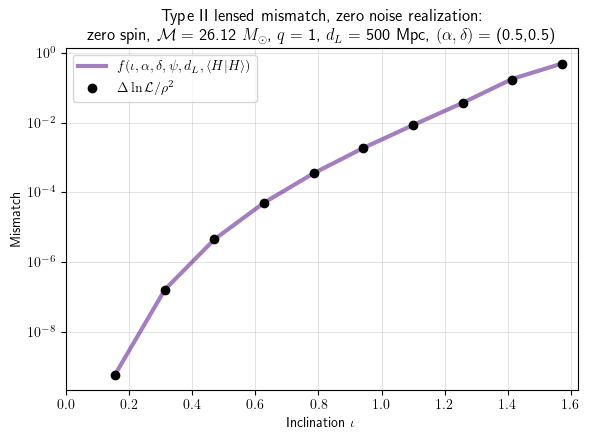

In [14]:
# plot
mismatches = maxlnlike_diffs / rhosqs
expected_mismatches = expected_diffs / rhosqs
fig, ax = plt.subplots(figsize=(6,4.5), tight_layout=True)
ax.plot(iotas, expected_mismatches, c='indigo', alpha=0.5, lw=3, label=labels[0])
ax.plot(iotas, mismatches, marker='o', c='k', ls='None', label=labels[1])
ax.axhline(0., alpha=0.5, lw=0.5, c='k')
ax.set_xlim(min(iotas), max(iotas) + .05)
ax.grid(alpha=0.5, lw=0.5)
ax.set_xlabel(r'Inclination $\iota$')
ax.set_ylabel(r'Mismatch')
ax.semilogy()
ax.legend()
ax.set_title(f'Type II lensed mismatch, zero noise realization:\n'r'zero spin, $\mathcal M=$ ' +
             f'{mchirp:.2f}'r' $M_\odot$, $q=$ 1, $d_L=$ ' + \
             f'{pars_to_inject['d_luminosity']:.0f} Mpc, ' + \
                r'$(\alpha,\delta)=$ 'f'({pars_to_inject['ra']:.1f},{pars_to_inject['dec']:.1f})')

### turn on noise

In [15]:
# do this for a range of inclinations
seed = 12
approximant = 'IMRPhenomXPHM'

iotas = np.arange(0., np.pi / 2 + 0.01, 0.05 * np.pi)

fn = 'mismatches_iota_noise.npy'
if os.path.exists(fn):
    res = np.load(fn, allow_pickle=True).item()
    maxlnlike_diffs = res['maxlnlike_diffs']
    expected_diffs = res['expected_diffs']
    rhosqs = res['rhosqs']
else:
    maxlnlike_diffs = np.empty_like(iotas)
    expected_diffs = np.empty_like(iotas)
    rhosqs = np.empty_like(iotas)

    for i, iota in enumerate(iotas):
        print(f"iota = {iota / np.pi:.2f}π")

        ed_u = create_injection(pars_to_inject | dict(iota = iota), seed=seed, approximant=approximant)
        # get the full injected parameter dictionary
        injected_par_dic = ed_u.injection['par_dic']

        # fast likelihood maximization to find the reference waveform
        mchirp = gw_utils.m1m2_to_mchirp(pars_to_inject['m1'], pars_to_inject['m2'])
        prior_class = 'IntrinsicLVCPrior'
        post = cogwheel.posterior.Posterior.from_event(
            ed_u,
            mchirp,
            approximant,
            prior_class,
            ref_wf_finder_kwargs={
                'f_ref': injected_par_dic['f_ref'],
                'time_range': (-0.1, 0.1)
            }
        )
        maxlnlike_diffs[i], expected_diffs[i], rhosqs[i] = compute_mismatches(post, ed_u, noise=True, plot=False, verbose=False)

    res = {
        'pars_to_inject' : pars_to_inject,
        'iotas' : iotas,
        'maxlnlike_diffs' : maxlnlike_diffs,
        'expected_diffs' : expected_diffs,
        'rhosqs' : rhosqs
    }
    np.save(fn, res)

Text(0.5, 1.0, 'Type II lensed mismatch (with noise):\nzero spin, $\\mathcal M=$ 26.12 $M_\\odot$, $q=$ 1, $d_L=$ 500 Mpc, $(\\alpha,\\delta)=$ (0.5,0.5)')

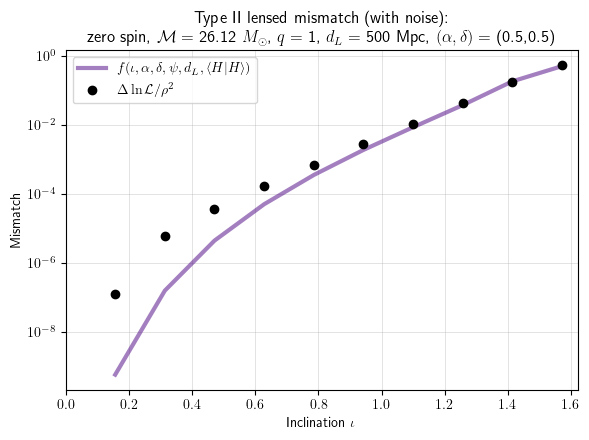

In [16]:
# plot
mismatches = maxlnlike_diffs / rhosqs
expected_mismatches = expected_diffs / rhosqs
fig, ax = plt.subplots(figsize=(6,4.5), tight_layout=True)
ax.plot(iotas, expected_mismatches, c='indigo', alpha=0.5, lw=3, label=labels[0])
ax.plot(iotas, mismatches, marker='o', c='k', ls='None', label=labels[1])
ax.axhline(0., alpha=0.5, lw=0.5, c='k')
ax.set_xlim(min(iotas), max(iotas) + .05)
ax.grid(alpha=0.5, lw=0.5)
ax.set_xlabel(r'Inclination $\iota$')
ax.set_ylabel(r'Mismatch')
ax.semilogy()
ax.legend()
ax.set_title(f'Type II lensed mismatch (with noise):\n'r'zero spin, $\mathcal M=$ ' +
             f'{mchirp:.2f}'r' $M_\odot$, $q=$ 1, $d_L=$ ' + \
             f'{pars_to_inject['d_luminosity']:.0f} Mpc, ' + \
                r'$(\alpha,\delta)=$ 'f'({pars_to_inject['ra']:.1f},{pars_to_inject['dec']:.1f})')

### vary mass ratio

In [17]:
# do this for a range of inclinations
seed = 12
approximant = 'IMRPhenomXPHM'

qs = np.arange(0.1, 1.01, 0.1)
iotas = np.arange(0., np.pi / 2 + 0.01, 0.05 * np.pi)

# load these results
fn = 'mismatches_iota_q.npy'
if os.path.exists(fn):
    res = np.load(fn, allow_pickle=True).item()
    maxlnlike_diffs = res['maxlnlike_diffs']
    expected_diffs = res['expected_diffs']
    rhosqs = res['rhosqs']
else:
    maxlnlike_diffs = np.empty((len(qs), len(iotas)))
    expected_diffs = np.empty_like(maxlnlike_diffs)
    rhosqs = np.empty_like(maxlnlike_diffs)

    mchirp = gw_utils.m1m2_to_mchirp(pars_to_inject['m1'], pars_to_inject['m2'])

    for j, q in enumerate(qs):
        print(f"q = {q:.1f}")
        for i, iota in enumerate(iotas):
            print(f"iota = {iota / np.pi:.2f}π", end="\r")

            # keep chirp mass fixed but adjust individual masses
            m1, m2 = helpers.m1_m2_from_mchirp_q(mchirp, q)

            ed_u = create_injection(pars_to_inject | dict(iota=iota, m1=m1, m2=m2), seed=seed, approximant=approximant)
            # get the full injected parameter dictionary
            injected_par_dic = ed_u.injection['par_dic']

            # fast likelihood maximization to find the reference waveform
            mchirp = gw_utils.m1m2_to_mchirp(pars_to_inject['m1'], pars_to_inject['m2'])
            prior_class = 'IntrinsicLVCPrior'
            post = cogwheel.posterior.Posterior.from_event(
                ed_u,
                mchirp,
                approximant,
                prior_class,
                ref_wf_finder_kwargs={
                    'f_ref': injected_par_dic['f_ref'],
                    'time_range': (-0.1, 0.1)
                }
            )
            maxlnlike_diffs[j,i], expected_diffs[j,i], rhosqs[j,i] = compute_mismatches(post, ed_u,
                                                                                        noise=False, plot=False, verbose=False)
    res = {
        'pars_to_inject' : pars_to_inject,
        'iotas' : iotas,
        'qs' : qs,
        'maxlnlike_diffs' : maxlnlike_diffs,
        'expected_diffs' : expected_diffs,
        'rhosqs' : rhosqs
    }
    np.save(fn, res)

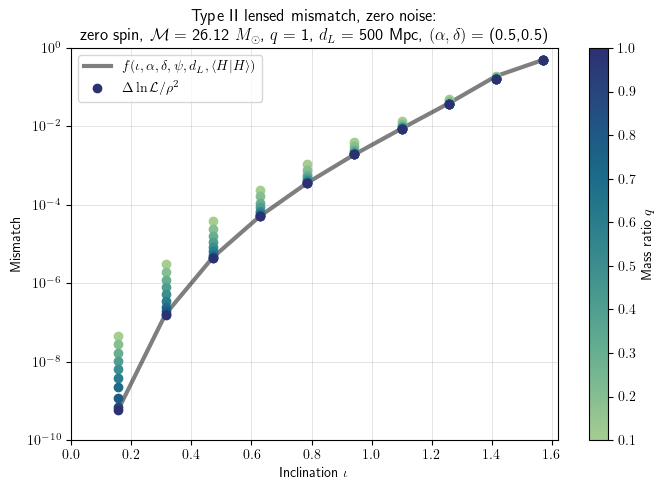

In [19]:
# plot
mismatches = maxlnlike_diffs / rhosqs
expected_mismatches = expected_diffs / rhosqs
fig, ax = plt.subplots(figsize=(7,5), tight_layout=True)
norm = mpl.colors.Normalize(vmin=min(qs), vmax=max(qs))
smap = mpl.cm.ScalarMappable(norm=norm, cmap=sns.color_palette('crest', as_cmap=True))
ax.plot(iotas, expected_mismatches[0], c='k', alpha=0.5, lw=3, label=labels[0])
for i, q in enumerate(qs):
    label = labels[1] if q == qs[-1] else None
    ax.plot(iotas, mismatches[i], marker='o', c=smap.to_rgba(q), ls='None', label=label)
ax.axhline(0., alpha=0.5, lw=0.5, c='k')
ax.set_xlim(min(iotas), max(iotas) + .05)
ax.grid(alpha=0.5, lw=0.5)
ax.set_ylim(1e-10, 1.)
ax.set_xlabel(r'Inclination $\iota$')
ax.set_ylabel(r'Mismatch')
ax.semilogy()
ax.legend()
ax.set_title(f'Type II lensed mismatch, zero noise:\n'r'zero spin, $\mathcal M=$ ' +
             f'{mchirp:.2f}'r' $M_\odot$, $q=$ 1, $d_L=$ ' + \
             f'{pars_to_inject['d_luminosity']:.0f} Mpc, ' + \
                r'$(\alpha,\delta)=$ 'f'({pars_to_inject['ra']:.1f},{pars_to_inject['dec']:.1f})')
fig.colorbar(smap, ax=ax, label=r'Mass ratio $q$')

### injection results

In [3]:
# load one injection result
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
idx = 0
# load the sampler
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
samples_dir = os.path.join(eventdir, f'run_0')
sampler = utils.read_json(os.path.join(samples_dir, 'Sampler.json'))

In [4]:
# what are the injected parameters?
like = sampler.posterior.likelihood
injected_par_dic = like.event_data.injection['par_dic']
# what's the SNR?
rho = np.sqrt(np.sum(like.event_data.injection['h_h']))
print(f"{eventname}: SNR is {rho:.1f}")
print(f"inclination is {injected_par_dic['iota'] / np.pi:.2f}π")
print("\ninjected parameters\n"+"=" * 30)
for key, val in injected_par_dic.items():
    if key not in ['f_ref', 'l1', 'l2']:
        print(f"{key:<16}:{val:>13.3f}")

GW12_0: SNR is 134.1
inclination is 0.46π

injected parameters
m1              :       52.633
m2              :       25.228
s1z             :        0.129
s2z             :       -0.391
psi             :        1.832
iota            :        1.454
s1x_n           :       -0.692
s1y_n           :       -0.111
s2x_n           :       -0.216
s2y_n           :       -0.133
ra              :        2.689
dec             :        0.268
t_geocenter     :       -0.036
phi_ref         :        3.547
d_luminosity    :       64.890


In [5]:
# we can also look at par_dic_0, for context: this is the params of the best-fit unlensed waveform to the lensed data
print("par_dic_0\n"+"=" * 30)
for key, val in like.par_dic_0.items():
    if key not in ['f_ref', 'l1', 'l2']:
        print(f"{key:<16}:{val:>13.3f}")
print(f"max ln likelihood of the lensed data given par_dic_0 is {like.lnlike_fft(like.par_dic_0):.1f}")

par_dic_0
d_luminosity    :       87.626
dec             :        0.264
iota            :        2.142
m1              :       44.424
m2              :       29.209
phi_ref         :        1.566
psi             :        0.000
ra              :        2.590
s1x_n           :        0.000
s1y_n           :        0.000
s1z             :       -0.321
s2x_n           :        0.000
s2y_n           :        0.000
s2z             :       -0.321
t_geocenter     :       -0.037
max ln likelihood of the lensed data given par_dic_0 is 8174.1


In [6]:
# unlens the event data: reinstantiate and get the unlensed likelihood
event_data_u = like.event_data.reinstantiate(strain=like.event_data.strain * -1j)
like_u = like.reinstantiate(event_data=event_data_u)

# what's the likelihood of the unlensed event data given the injected parameters?
maxlnlike_u = like_u.lnlike_fft(injected_par_dic)
print(f"max ln likelihood of the unlensed data given injected parameters is {maxlnlike_u:.1f}")

max ln likelihood of the unlensed data given injected parameters is 8897.1


In [7]:
# what's the likelihood of the lensed event data given the imposter parameters?
shifts = [+np.pi/4, -np.pi/4]
shift_strs = ['+ pi/4', '- pi/4']
shift_strs_latex = [r'$+ \pi/4$', r'$- \pi/4$']
maxlnlikes = []
for shift_str, shift in zip(shift_strs, shifts):
    maxlnlike_imposter = like.lnlike_fft(injected_par_dic | dict(psi=injected_par_dic['psi'] + shift))
    print(f"max ln likelihood of the lensed data given unlensed imposter (psi -> psi {shift_str}) is {maxlnlike_imposter:.1f}")
    maxlnlikes.append(maxlnlike_imposter)
# take the max
idx_max = np.argmax(maxlnlikes)
maxlnlike_imposter = maxlnlikes[idx_max]
shift = shifts[idx_max]
print(f"taking psi {shift_strs[idx_max]} as the best imposter")

max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is -9077.8
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -7214.9
taking psi - pi/4 as the best imposter


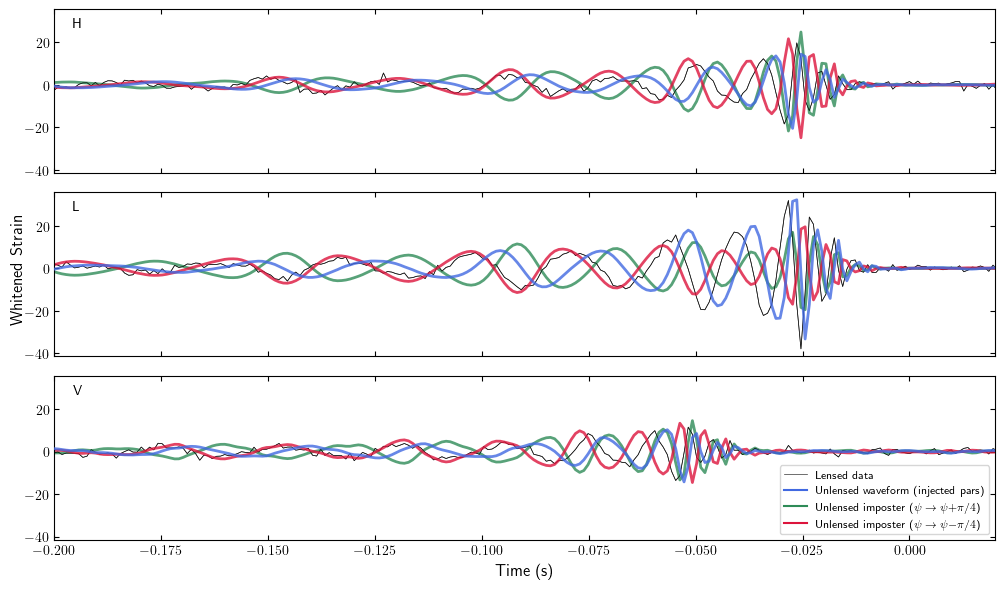

In [8]:
# compare the lensed and unlensed waveforms
kwargs = dict(trng=(-.2, .02), alpha=0.8, lw=2, data_plot_kwargs=dict(c='k', lw=0.5, alpha=0.8))
like_u.plot_whitened_wf(injected_par_dic, c='royalblue', figsize=(10,6), zorder=100, plot_data=False, **kwargs)
labels = ['Lensed data', 'Unlensed waveform (injected pars)']
custom_lines = [Line2D([0], [0], **kwargs['data_plot_kwargs']), Line2D([0], [0], c='royalblue')]
# like.plot_whitened_wf(like.par_dic_0, c='seagreen', fig=plt.gcf(), **kwargs)
cs = ['seagreen', 'crimson']
for shift, shift_str, c in zip(shifts, shift_strs_latex, cs):
    imposter_par_dic = injected_par_dic | dict(psi=injected_par_dic['psi'] + shift)
    like.plot_whitened_wf(imposter_par_dic, c=c, fig=plt.gcf(), **kwargs)
    labels.append(r'Unlensed imposter ($\psi\rightarrow\psi$'f'{shift_str})')
    custom_lines.append(Line2D([0], [0], c=c))
plt.gca().legend(custom_lines, labels, loc=4, fontsize=8)

In [9]:
# calculate the likelihood on a grid of distance
dL_grid = np.arange(10., 3001., 5.) # Mpc
# likelihood of the unlensed data given the injected pars: we expect this to ~recover the injected dL
lnlike_grid = np.array([
    like_u.lnlike_fft(injected_par_dic | dict(d_luminosity=dL)) for dL in dL_grid
])
# likelihood of the lensed data given the imposter pars
lnlike_imposter_grid = np.array([
    like.lnlike_fft(injected_par_dic | dict(psi=injected_par_dic['psi'] + shift, d_luminosity=dL)) for dL in dL_grid
])

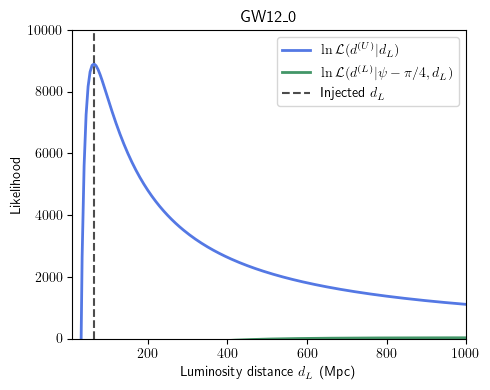

In [10]:
fig, ax = plt.subplots(figsize=(5,4), tight_layout=True)
c1, c2 = 'royalblue', 'seagreen'
ax.plot(dL_grid, lnlike_grid, c=c1, ls='-', alpha=0.9, lw=2, label=r'$\ln\mathcal L(d^{(U)}|d_L)$')
ax.plot(dL_grid, lnlike_imposter_grid, c=c2, ls='-', alpha=0.9, lw=2, label=r'$\ln\mathcal L(d^{(L)}|\psi-\pi/4,d_L)$')
ax.axvline(injected_par_dic['d_luminosity'], c='k', ls='--', alpha=0.7, label=r'Injected $d_L$')
ax.set_xlabel(r'Luminosity distance $d_L$ (Mpc)')
ax.set_ylabel(r'Likelihood')
ax.set_xlim(10., 1000.)
ax.set_ylim(0., 10000)
ax.set_title(eventname)
ax.legend()

In [11]:
# maximize the likelihood over distance given the unlensed imposter
res = helpers.max_over_distance(like, injected_par_dic, shift, print_res=True)
max_dL = res['x']
maxlnlike_imposter_dL = -res['fun']
print(f"max ln likelihood given imposter, maximized over distance, is {maxlnlike_imposter_dL:.1f} at {max_dL:.1f} Mpc")

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -26.624255888106983
       x: 1135.0593476973604
     nit: 18
    nfev: 45
max ln likelihood given imposter, maximized over distance, is 26.6 at 1135.1 Mpc


In [12]:
# now we see if maxlike - maxlike_imposter_dL ~ the expected scaling for this event ?!
maxlnlike_u - maxlnlike_imposter_dL

np.float64(8870.448888323353)

In [13]:
rhosq = like.event_data.injection['h_h'].sum()
print(f"expected mismatch is {(maxlnlike_u - maxlnlike_imposter_dL) / rhosq:.3f}")

expected mismatch is 0.494


### expected scaling

$$
\ln\mathcal L^\mathrm{max}_\mathrm{II} - \ln\mathcal L^\mathrm{max}_\mathrm{I} = \frac{\rho^2}{2}\left(1 - \frac{\left(\mu\varepsilon\sum_d \vert\vec F^{(d)}\vert^2\langle H^{(d)}|H^{(d)}\rangle\right)^2}{\sum_d\left[\left(\varepsilon F_+^{(d)}\right)^2 + \left(\mu F_\times^{(d)}\right)^2\right]\langle H^{(d)}|H^{(d)}\rangle\sum_d\left[\left(\varepsilon F_\times^{(d)}\right)^2 + \left(\mu F_+^{(d)}\right)^2\right]\langle H^{(d)}|H^{(d)}\rangle}\right)
$$
with $\mu\equiv\cos\iota$, $\varepsilon\equiv(1+\mu^2)/2$, and $H^{(d)}\equiv S_m^{(d)} h_m^{(d)}$

In [17]:
# we need HH
like = sampler.posterior.likelihood
# which harmonic modes are present in the signal?
harmonic_modes = like.waveform_generator.harmonic_modes
m_arr = like.waveform_generator.m_arr
print(f"harmonic modes: ", harmonic_modes)
# get the injected parameters
par_dict = like.event_data.injection['par_dic']
# waveform (frequency domain) in each detector
h = like._get_h_f(par_dict, by_m=True)
H = np.zeros_like(h[0,:])
for m, h_m in zip(m_arr, h):
    H += helpers.S_m(m, par_dict['iota']) * h_m
# and the inner product
HH = like._compute_h_h(H)

# antenna response functions
init_dict = like.event_data.get_init_dict()
fplus, fcross = gw_utils.fplus_fcross(init_dict['detector_names'],
                                        par_dict['ra'], par_dict['dec'], par_dict['psi'],
                                        init_dict['tgps'])

# then the expected ln Bayes
rhosq = np.sum(like.event_data.injection['h_h'])
mu = np.cos(par_dict['iota'])
exp_mismatch = helpers.expected_mismatch_with_HH(fplus, fcross, mu, HH)
print(f"expected mismatch = {exp_mismatch:.3f}")
expected_lnB = rhosq * exp_mismatch
print(f"expected lnB = {expected_lnB:.2f}")
# how does this compare to the "old" (incorrect) expected lnB?
print(f"(old expected lnB = {rhosq * helpers.expected_mismatch(fplus, fcross, mu):.2f})")

harmonic modes:  [(2, 2), (2, 1), (3, 3), (3, 2), (4, 4)]
expected mismatch = 0.391
expected lnB = 7028.39
(old expected lnB = 7268.90)


In [18]:
# what lnB did we actually get?
_, _, samples_dir = helpers.load_event_data_and_posterior_samples(eventdir, eventname)
lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
med, std = np.load(lnBayes_fn)
print(f"computed lnB = {med:.2f} ± {std:.2f}")

FileNotFoundError: could not find posterior samples at /home/abbye.williams/GWPE/data/injections/Halton/IMRPhenomXPHM/IntrinsicLVCPrior/GW12_0/run_9

### loop: compare $\ln\mathcal L_\mathrm{II}^\mathrm{max}(\psi) - \ln\mathcal L_\mathrm{I}^\mathrm{max}(\psi\pm\pi/4)$ to the formula for different events

In [54]:
def compute_max_lnlikes(sampler, verbose=True):
    # injection parameters
    like = sampler.posterior.likelihood
    ed = like.event_data
    injected_par_dic = ed.injection['par_dic']
    iota = injected_par_dic['iota']
    rho = np.sqrt(np.sum(ed.injection['h_h']))
    if verbose:
        print(f"{ed.eventname}: SNR is {rho:.1f}")
        print(f"inclination is {iota / np.pi:.2f}π")

    # zero noise realization
    ed_u_0 = ed.reinstantiate(strain=np.zeros_like(ed.strain))
    ed_u_0.inject_signal(par_dic=injected_par_dic, approximant=approximant)
    like_u_0 = sampler.posterior.likelihood
    like_u_0.event_data = ed_u_0
    like_u_0._set_summary()
    like_u_0.asd_drift = None

    # Type II lens
    ed_0 = ed_u_0.reinstantiate(strain=ed_u_0.strain * 1j)
    like_0 = deepcopy(like_u_0)
    like_0.event_data = ed_0
    like_0._set_summary()
    like_0.asd_drift = None

    # what's the likelihood of the unlensed event data given the injected parameters?
    maxlnlike_u = like_u_0.lnlike_fft(injected_par_dic)
    print(f"max ln likelihood of the unlensed data given injected parameters is {maxlnlike_u:.1f}")

    # what's the likelihood of the lensed event data given the imposter parameters?
    shifts = [+np.pi/4, -np.pi/4]
    shift_strs = ['+ pi/4', '- pi/4']
    maxlnlikes = []
    for shift_str, shift in zip(shift_strs, shifts):
        maxlnlike_imposter = like_0.lnlike_fft(injected_par_dic | dict(psi=injected_par_dic['psi'] + shift))
        if verbose:
            print(f"max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi {shift_str}) is {maxlnlike_imposter:.1f}")
        maxlnlikes.append(maxlnlike_imposter)
    # take the max
    idx_max = np.argmax(maxlnlikes)
    maxlnlike_imposter = maxlnlikes[idx_max]
    shift = shifts[idx_max]
    if verbose:
        print(f"taking psi {shift_strs[idx_max]} as the best imposter")
    
    # maximize the likelihood over distance given the unlensed imposter
    maxD_res = helpers.max_over_distance(like_0, injected_par_dic, shift)
    maxlnlike_imposter_dL = -maxD_res['fun']
    if verbose:
        print(f"max ln likelihood given imposter, maximized over distance, is {maxlnlike_imposter_dL:.1f} at {maxD_res['x']:.1f} Mpc")

    maxlnlike_diff = maxlnlike_u - maxlnlike_imposter_dL
    lnlike_mismatch = (maxlnlike_u - maxlnlike_imposter_dL) / rho**2
    print(f"max lnlike difference (mismatch) = {maxlnlike_diff:.1f} ({lnlike_mismatch:.3f})")

    ## EXPECTED SCALING FROM FORMULA ##
    # waveform (frequency domain) in each detector
    HH = helpers.compute_HH(like_0)

    # antenna response functions
    init_dict = ed.get_init_dict()
    fplus, fcross = gw_utils.fplus_fcross(init_dict['detector_names'],
                                            injected_par_dic['ra'], injected_par_dic['dec'],
                                            injected_par_dic['psi'], init_dict['tgps'])

    # then the expected ln Bayes
    mu = np.cos(injected_par_dic['iota'])
    formula_mismatch = helpers.expected_mismatch_with_HH(fplus, fcross, mu, HH)
    expected_lnB = rho**2 * formula_mismatch
    print(f"expected lnB (mismatch) from formula = {expected_lnB:.2f} ({formula_mismatch:.3f})")

    res = {
        'lnlike_mismatch' : lnlike_mismatch,
        'formula_mismatch' : formula_mismatch,
        'shift' : shift,
        'HH' : HH,
        'rhosq' : rho**2,
        'max_lnlike_unlensed' : maxlnlike_u,
        'max_lnlike_imposter' : maxlnlike_imposter_dL
    }

    return res

GW12_1: SNR is 70.7
inclination is 0.54π
max ln likelihood of the unlensed data given injected parameters is 2501.0


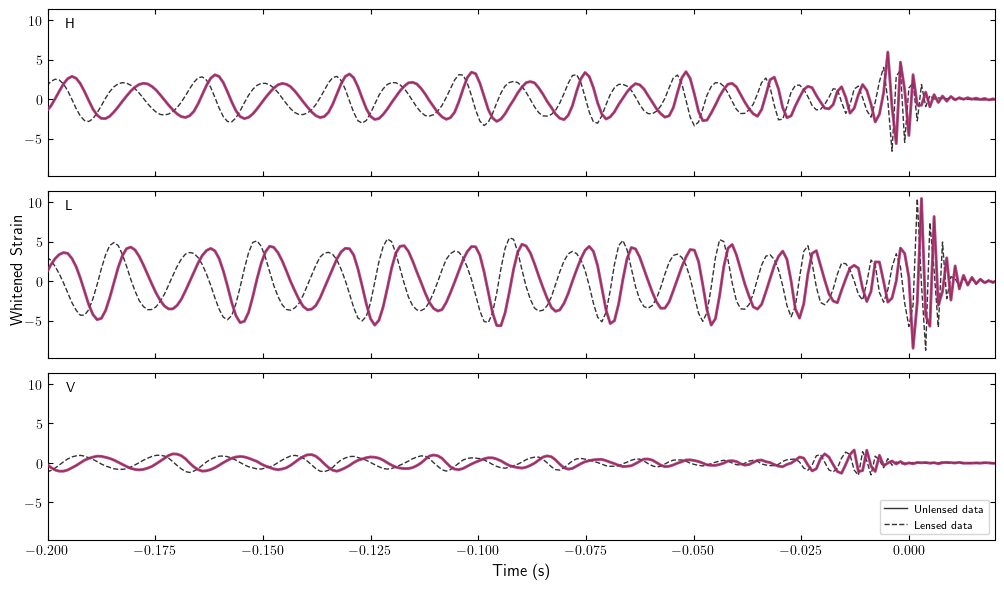

In [55]:
# load a sampler
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
idx = 1
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
samples_dir = os.path.join(eventdir, f'run_0')
sampler = utils.read_json(os.path.join(samples_dir, 'Sampler.json'))

# injection parameters
like = sampler.posterior.likelihood
ed = like.event_data
injected_par_dic = ed.injection['par_dic']
iota = injected_par_dic['iota']
rho = np.sqrt(np.sum(ed.injection['h_h']))
print(f"{ed.eventname}: SNR is {rho:.1f}")
print(f"inclination is {iota / np.pi:.2f}π")

# zero noise realization
ed_u_0 = ed.reinstantiate(strain=np.zeros_like(ed.strain))
ed_u_0.inject_signal(par_dic=injected_par_dic, approximant=approximant)
like_u_0 = sampler.posterior.likelihood
like_u_0.event_data = ed_u_0
like_u_0._set_summary()
like_u_0.asd_drift = None

# Type II lens
ed_0 = ed_u_0.reinstantiate(strain=ed_u_0.strain * 1j)
like_0 = deepcopy(like_u_0)
like_0.event_data = ed_0
like_0._set_summary()
like_0.asd_drift = None

# what's the likelihood of the unlensed event data given the injected parameters?
maxlnlike_u = like_u_0.lnlike_fft(injected_par_dic)
print(f"max ln likelihood of the unlensed data given injected parameters is {maxlnlike_u:.1f}")

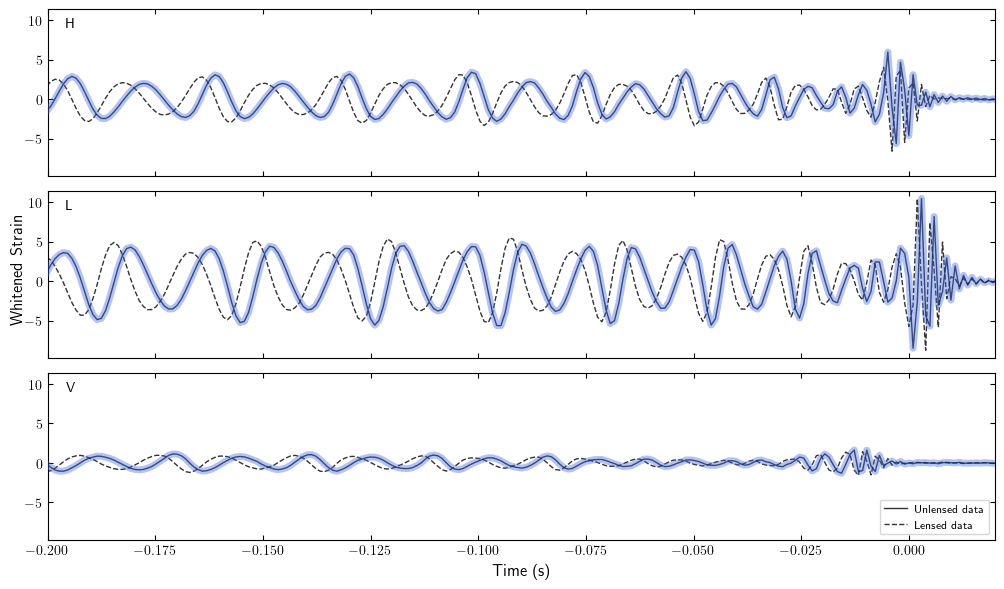

In [60]:
# plot
kwargs = dict(trng=(-.2, .02), alpha=0.4, lw=5, data_plot_kwargs=dict(c='k', lw=1, alpha=0.8))
lensed_data_plot_kwargs = kwargs['data_plot_kwargs'].copy()
lensed_data_plot_kwargs['ls'] = '--'
like_u_0.plot_whitened_wf(injected_par_dic, c='royalblue', figsize=(10,6), zorder=100, plot_data=True, **kwargs)
like_0.plot_whitened_wf(injected_par_dic, fig=plt.gcf(), zorder=100, plot_data=True,
                        **kwargs | dict(data_plot_kwargs=lensed_data_plot_kwargs, ls='None'))
labels = ['Unlensed data', 'Lensed data']
custom_lines = [Line2D([0], [0], **kwargs['data_plot_kwargs']), Line2D([0], [0], **lensed_data_plot_kwargs)]
plt.gca().legend(custom_lines, labels, loc=4, fontsize=8)

In [61]:
# load one injection result
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12

lnlike_mismatches = {}
formula_mismatches = {}
diffs = {}
imposters = {}
for idx in range(100):
    # load the sampler
    eventname = f'GW{seed}_{idx}'
    eventdir = os.path.join(resdir, eventname)
    samples_dir = os.path.join(eventdir, f'run_0')
    save_fn = os.path.join(samples_dir, 'mismatches_zeronoise.npy')

    if os.path.exists(save_fn):
        print(f"file exists for {eventname}. loading mismatches")
        res = np.load(save_fn, allow_pickle=True).item()
    else:
        sampler = utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
        res = compute_max_lnlikes(sampler)
        np.save(save_fn, res)

    lnlike_mismatches[idx] = res['lnlike_mismatch']
    formula_mismatches[idx] = res['formula_mismatch']
    diffs[idx] = res['lnlike_mismatch'] - res['formula_mismatch']
    # and save the imposter (± pi/4)
    imposters[idx] = res['shift']

GW12_0: SNR is 134.1
inclination is 0.46π
max ln likelihood of the unlensed data given injected parameters is 8985.4
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is -9287.6
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is -7277.1
taking psi - pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 30.5 at 1069.3 Mpc
max lnlike difference (mismatch) = 8954.9 (0.498)
expected lnB (mismatch) from formula = 7019.89 (0.391)


GW12_1: SNR is 70.7
inclination is 0.54π
max ln likelihood of the unlensed data given injected parameters is 2501.0
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is -7650.5
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is 1937.5
taking psi - pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 2011.4 at 126.4 Mpc
max lnlike difference (mismatch) = 489.6 (0.098)
expected lnB (mismatch) from formula = 1922.10 (0.384)


GW12_2: SNR is 80.5
inclination is 0.40π
max ln likelihood of the unlensed data given injected parameters is 3240.6
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is 2417.7
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is -6046.6
taking psi + pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 2467.8 at 74.9 Mpc
max lnlike difference (mismatch) = 772.8 (0.119)
expected lnB (mismatch) from formula = 760.10 (0.117)


GW12_3: SNR is 35.2
inclination is 0.52π
max ln likelihood of the unlensed data given injected parameters is 617.8
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is -2884.9
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is -211.8
taking psi - pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 288.4 at 525.7 Mpc
max lnlike difference (mismatch) = 329.4 (0.267)
expected lnB (mismatch) from formula = 477.26 (0.386)


GW12_4: SNR is 12.7
inclination is 0.83π
max ln likelihood of the unlensed data given injected parameters is 80.4
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is -237.6
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is 80.3
taking psi - pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 80.3 at 1745.5 Mpc
max lnlike difference (mismatch) = 0.1 (0.001)
expected lnB (mismatch) from formula = 0.00 (0.000)


...

GW12_95: SNR is 70.8
inclination is 0.26π
max ln likelihood of the unlensed data given injected parameters is 2504.5
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is 1806.1
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is -6551.8
taking psi + pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 1839.9 at 129.1 Mpc
max lnlike difference (mismatch) = 664.6 (0.133)
expected lnB (mismatch) from formula = 11.08 (0.002)


GW12_96: SNR is 80.4
inclination is 0.72π
max ln likelihood of the unlensed data given injected parameters is 3231.8
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is -9252.4
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is 3213.7
taking psi - pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 3216.8 at 245.5 Mpc
max lnlike difference (mismatch) = 14.9 (0.002)
expected lnB (mismatch) from formula = 23.70 (0.004)


GW12_97: SNR is 35.1
inclination is 0.26π
max ln likelihood of the unlensed data given injected parameters is 614.3
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is 605.4
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is -1759.7
taking psi + pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 605.8 at 232.4 Mpc
max lnlike difference (mismatch) = 8.6 (0.007)
expected lnB (mismatch) from formula = 2.12 (0.002)


GW12_98: SNR is 12.7
inclination is 0.55π
max ln likelihood of the unlensed data given injected parameters is 80.2
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is -241.0
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is -148.3
taking psi - pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 2.8 at 1729.2 Mpc
max lnlike difference (mismatch) = 77.4 (0.483)
expected lnB (mismatch) from formula = 57.46 (0.358)


GW12_99: SNR is 25.5
inclination is 0.76π
max ln likelihood of the unlensed data given injected parameters is 325.8
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi + pi/4) is -989.9
max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi - pi/4) is 324.5
taking psi - pi/4 as the best imposter
max ln likelihood given imposter, maximized over distance, is 324.5 at 557.8 Mpc
max lnlike difference (mismatch) = 1.2 (0.002)
expected lnB (mismatch) from formula = 0.63 (0.001)


In [9]:
# \equiv(\mathrm{max}_D\ln\mathcal L(d^L|\vec\theta) - \mathrm{max}_D\ln\mathcal L(d^U|\vec\theta'))/\langle h|h\rangle

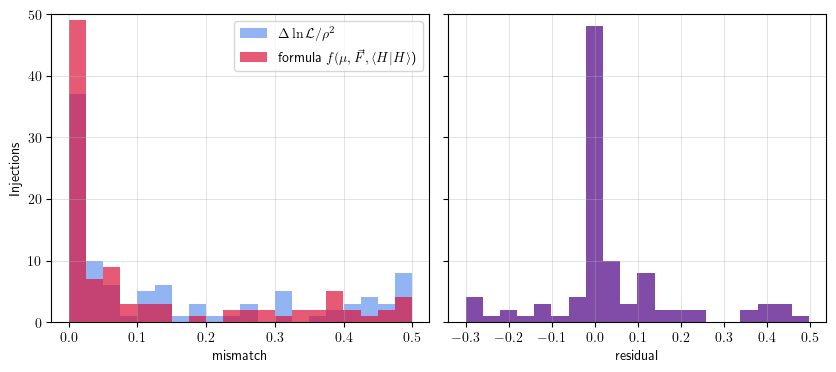

In [62]:
# plot these three distributions
fig, axs = plt.subplots(1, 2, figsize=(10,4), gridspec_kw=dict(wspace=0.05))
legend_labels = [r"$\Delta\ln\mathcal L/\rho^2$",
                 r'formula $f(\mu, \vec F,\langle H|H\rangle$)']
labels = ['mismatch', r'residual'] # ($\Delta\ln\mathcal L/\rho^2 - f(\mu,\vec F,\langle H|H\rangle)$)']
cs = ['cornflowerblue', 'crimson']
kwargs = dict(bins=20, alpha=0.7)
for dic, legend_label, c in zip([lnlike_mismatches, formula_mismatches], legend_labels, cs):
    _, _, _ = axs[0].hist(dic.values(), color=c, label=legend_label, **kwargs)
_, _, _ = axs[1].hist(diffs.values(), color='indigo', **kwargs)
for ax, label in zip(axs, labels):
    ax.grid(alpha=0.5, lw=0.5)
    ax.set_ylim(0., 50.)
    ax.set_xlabel(label)
axs[0].set_ylabel('Injections')
axs[0].legend()
_ = axs[1].set_yticklabels([])

In [63]:
iotas = {}
for idx in diffs.keys():
    eventname = f'GW{seed}_{idx}'
    ed = cogwheel.data.EventData.from_npz(filename=os.path.join(resdir, eventname, f'run_0', f'{eventname}.npz'))
    iotas[idx] = ed.injection['par_dic']['iota']
mus = np.array([
    np.cos(iota) for iota in iotas.values()
])

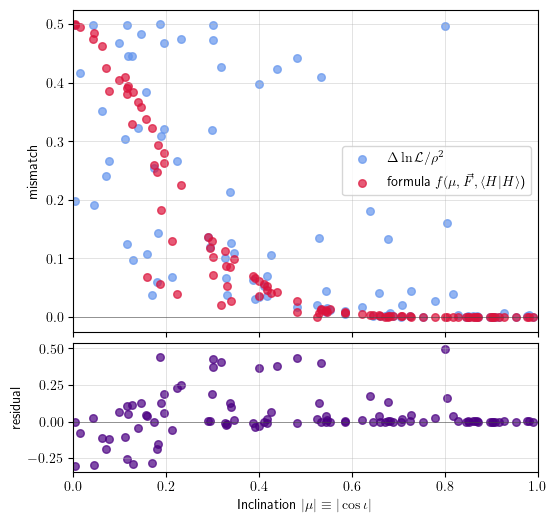

In [64]:
# does the difference in LHS and RHS depend on inclination?
fig, axs = plt.subplots(2, 1, figsize=(6,6), gridspec_kw=dict(height_ratios=[1., 0.4], hspace=0.05))
kwargs = dict(alpha=0.7, s=30)
axs[0].scatter(np.abs(mus), lnlike_mismatches.values(),
                c='cornflowerblue', label=legend_labels[0], **kwargs)
axs[0].scatter(np.abs(mus), formula_mismatches.values(), c='crimson', label=legend_labels[1], **kwargs)
axs[0].legend()
axs[1].scatter(np.abs(mus), diffs.values(), c='indigo', **kwargs)
axs[-1].set_xlabel(r'Inclination $|\mu|\equiv|\cos\iota|$')
_ = axs[0].set_xticklabels([])
for ax, label in zip(axs, labels):
    ax.set_ylabel(label)
    ax.set_xlim(0., 1.)
    ax.grid(alpha=0.5, lw=0.5)
    ax.axhline(0., c='k', lw=0.5, alpha=0.5)

In [65]:
# how many imposters are ± π/4?
idx_pos = []
idx_neg = []
for idx, shift in imposters.items():
    if shift == np.pi / 4:
        idx_pos.append(True)
        idx_neg.append(False)
    elif shift == - np.pi / 4:
        idx_neg.append(True)
        idx_pos.append(False)
    else:
        print(f"shift for idx {idx} is {shift}")
print(f"{sum(idx_pos)} events have psi shift + π/4\n{sum(idx_neg)} events have psi shift - π/4")

43 events have psi shift + π/4
57 events have psi shift - π/4


In [66]:
# \equiv\mathrm{max}_D\ln\mathcal L(d^L|\vec\theta)$"f"\n"r"$-\mathrm{max}_D\ln\mathcal L(d^U|\vec\theta')

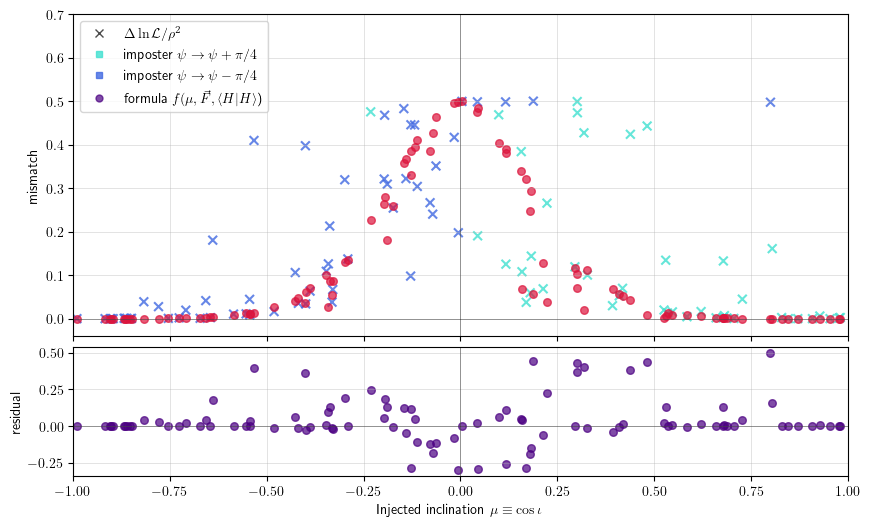

In [67]:
# does the difference in LHS and RHS depend on inclination?
fig, axs = plt.subplots(2, 1, figsize=(10,6), gridspec_kw=dict(height_ratios=[1., 0.4], hspace=0.05))

# let's color the injections by the best imposter (± π/4)
c1, c2 = 'turquoise', 'royalblue'
colors = np.full(len(mus), c1)
colors[idx_neg] = c2

lnlike_mis = np.array(list(lnlike_mismatches.values()))
axs[0].scatter(mus, lnlike_mis,
                c=colors, label=legend_labels[0], marker='x', alpha=0.8, s=40)
axs[0].scatter(mus, formula_mismatches.values(), c='crimson', label=legend_labels[1], alpha=0.7, s=30)
axs[0].set_ylim(-.04, 0.7)
axs[1].scatter(mus, diffs.values(), c='indigo', alpha=0.7, s=30)
axs[-1].set_xlabel(r'Injected inclination $\mu\equiv\cos\iota$')
_ = axs[0].set_xticklabels([])
for ax, label in zip(axs, labels):
    ax.set_ylabel(label)
    ax.set_xlim(-1., 1.)
    ax.axvline(0., c='k', alpha=0.5, lw=0.5)
    ax.grid(alpha=0.5, lw=0.5)
    ax.axhline(0., c='k', lw=0.5, alpha=0.5)

# custom legend
labels = [r"$\Delta\ln\mathcal L/\rho^2$",
          r'imposter $\psi\rightarrow\psi +\pi/4$',
          r'imposter $\psi\rightarrow\psi -\pi/4$',
          legend_labels[1]]
handles = [Line2D([0], [0], marker='x', alpha=0.7, ms=6, c='k', ls='None'),
           Line2D([0], [0], alpha=0.8, ms=5, marker='s', ls='None', c=c1),
           Line2D([0], [0], alpha=0.8, ms=5, marker='s', ls='None', c=c2),
           Line2D([0], [0], alpha=0.7, ms=5, marker='o', ls='None', c='indigo')]
axs[0].legend(labels=labels, handles=handles)

#### investigate the "flipped" imposters

In [10]:
# what are the two highest mismatches?
idx_highest = np.where(lnlike_mis > 0.55)[0]
mus_highest = mus[idx_highest]
lnlike_mis_highest = lnlike_mis[idx_highest]
# confirm that these shifts match the colors above
for i in idx_highest:
    print(f"idx {i}: shift = {imposters[i]:.4f}")

idx 35: shift = 0.7854
idx 38: shift = -0.7854


In [11]:
# mu > 0 but - π/4 shift
idx_outliers1 = np.where(mus[idx_neg] > 0)[0]
event_idx_outliers1 = np.arange(100)[idx_neg][idx_outliers1]
print(event_idx_outliers1)
# mu < 0 but + π/4 shift
idx_outliers2 = np.where(mus[idx_pos] < 0)[0]
event_idx_outliers2 = np.arange(100)[idx_pos][idx_outliers2]
print(event_idx_outliers2)
# combine these
event_idx_outliers = list(event_idx_outliers1) + list(event_idx_outliers2)

[ 0 20 38 52]
[35]


In [ ]:
# what are the likelihoods of the different imposters?
for idx in event_idx_outliers:
    # load the sampler
    eventname = f'GW{seed}_{idx}'
    eventdir = os.path.join(resdir, eventname)
    samples_dir = os.path.join(eventdir, f'run_0')
    sampler = utils.read_json(os.path.join(samples_dir, 'Sampler.json'))

    # injection parameters
    like = sampler.posterior.likelihood
    ed = like.event_data
    injected_par_dic = ed.injection['par_dic']
    iota = injected_par_dic['iota']
    rho = np.sqrt(np.sum(ed.injection['h_h']))
    print(f"{ed.eventname}: SNR is {rho:.1f}")
    print(f"inclination is {iota / np.pi:.2f}π")
    
    # unlens the event data: reinstantiate and get the unlensed likelihood
    ed_u = ed.reinstantiate(strain=ed.strain * -1j)
    like_u = like.reinstantiate(event_data=ed_u)

    # what's the likelihood of the unlensed event data given the injected parameters?
    maxlnlike_u = like_u.lnlike_fft(injected_par_dic)
    print(f"max ln likelihood of the unlensed data given injected parameters is {maxlnlike_u:.1f}")

    # what's the likelihood of the lensed event data given the imposter parameters?
    shifts = [+np.pi/4, -np.pi/4]
    shift_strs = ['+ pi/4', '- pi/4']
    maxlnlikes = []
    for shift_str, shift in zip(shift_strs, shifts):
        maxlnlike_imposter = like.lnlike_fft(injected_par_dic | dict(psi=injected_par_dic['psi'] + shift))
        print(f"max ln likelihood of the lensed data given unlensed imposter (psi -> psi {shift_str}) is {maxlnlike_imposter:.1f}")

GW12_0: SNR is 134.1
inclination is 0.46π


max ln likelihood of the unlensed data given injected parameters is 8897.1
max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is -9077.8
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -7214.9


GW12_20: SNR is 66.5
inclination is 0.50π
max ln likelihood of the unlensed data given injected parameters is 2193.7
max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is -1302.8
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -1038.0
GW12_38: SNR is 21.1
inclination is 0.20π
max ln likelihood of the unlensed data given injected parameters is 266.4
max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is -42.7
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -17.0
GW12_52: SNR is 24.9
inclination is 0.49π
max ln likelihood of the unlensed data given injected parameters is 298.1
max ln likelihood of the lensed data given unlensed imposter (psi -> psi + pi/4) is -103.5
max ln likelihood of the lensed data given unlensed imposter (psi -> psi - pi/4) is -23.3


no samples found for GW12_0. continuing
loaded posterior samples for GW12_20 run 0
ValueError: Too many bins for data range. Cannot create 44 finite-sized bins.. removing p_lensed and attempting to plot again...
loaded posterior samples for GW12_38 run 0
loaded posterior samples for GW12_52 run 0
loaded posterior samples for GW12_35 run 0


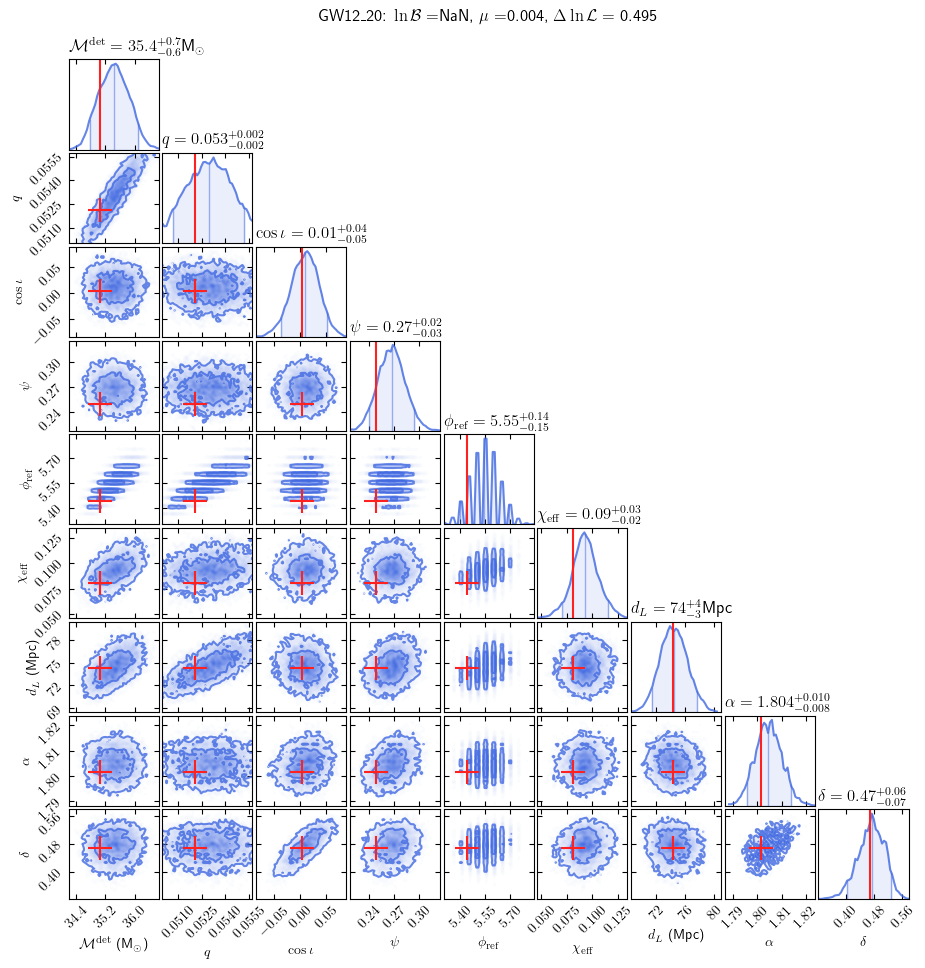

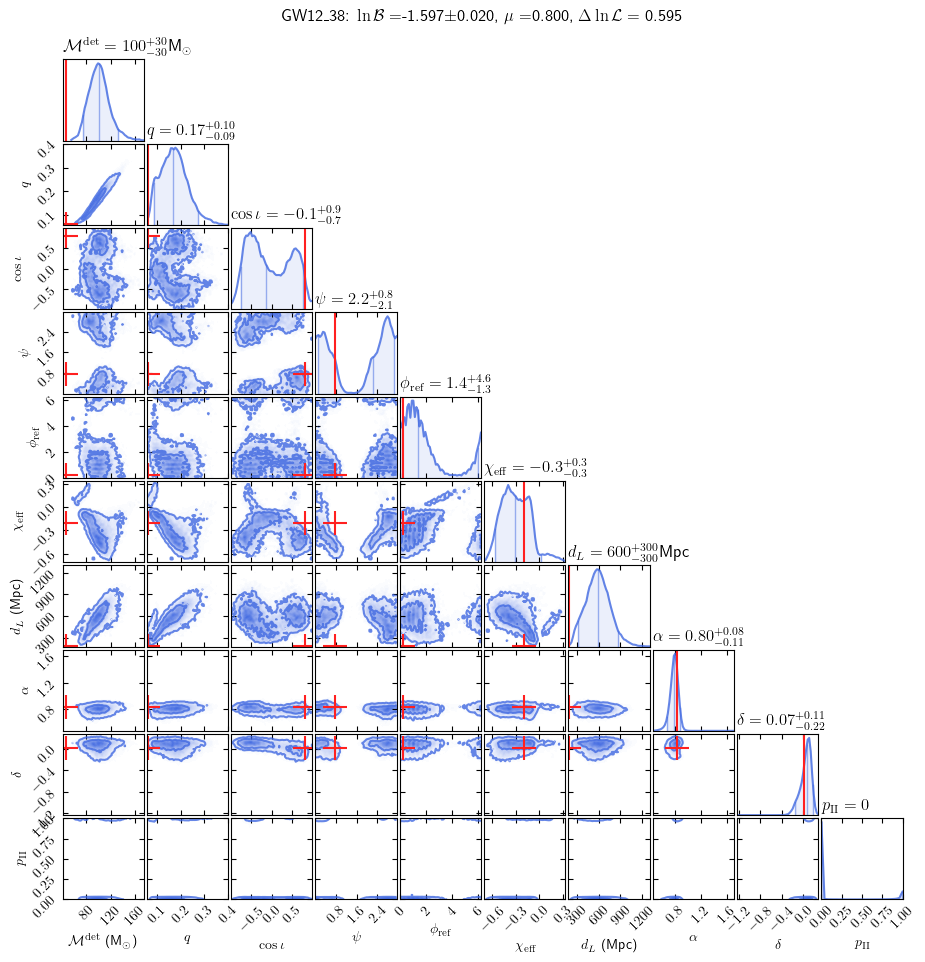

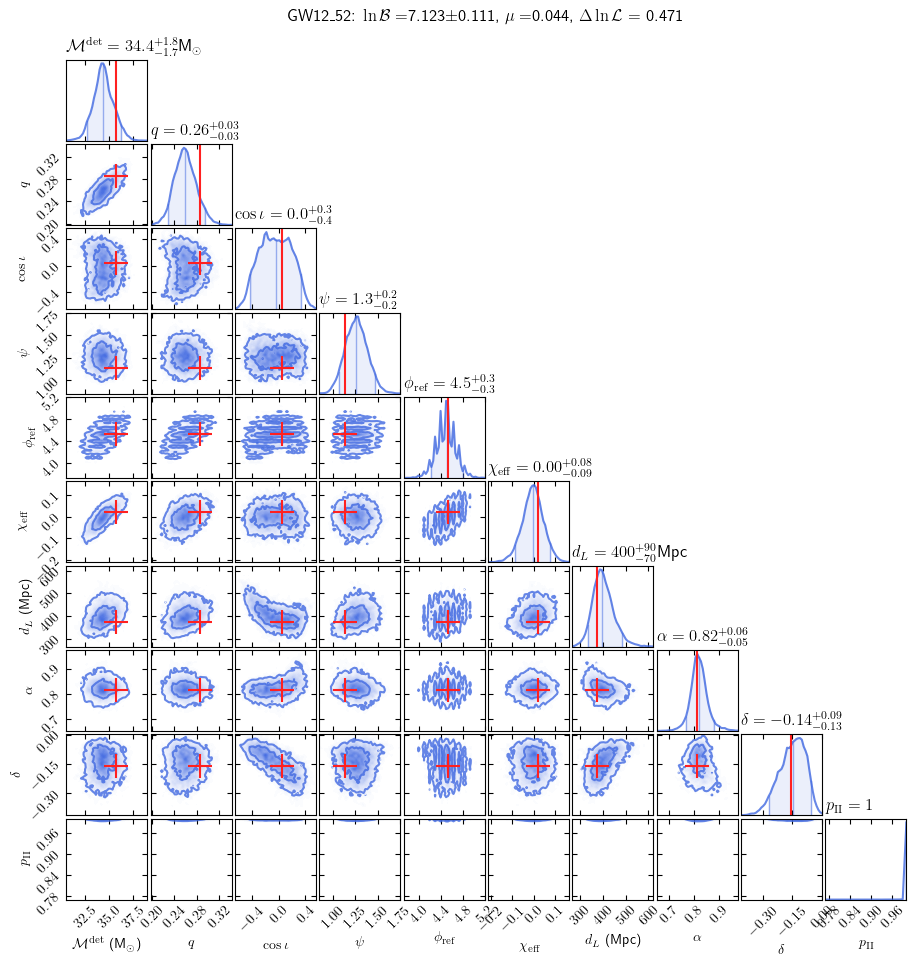

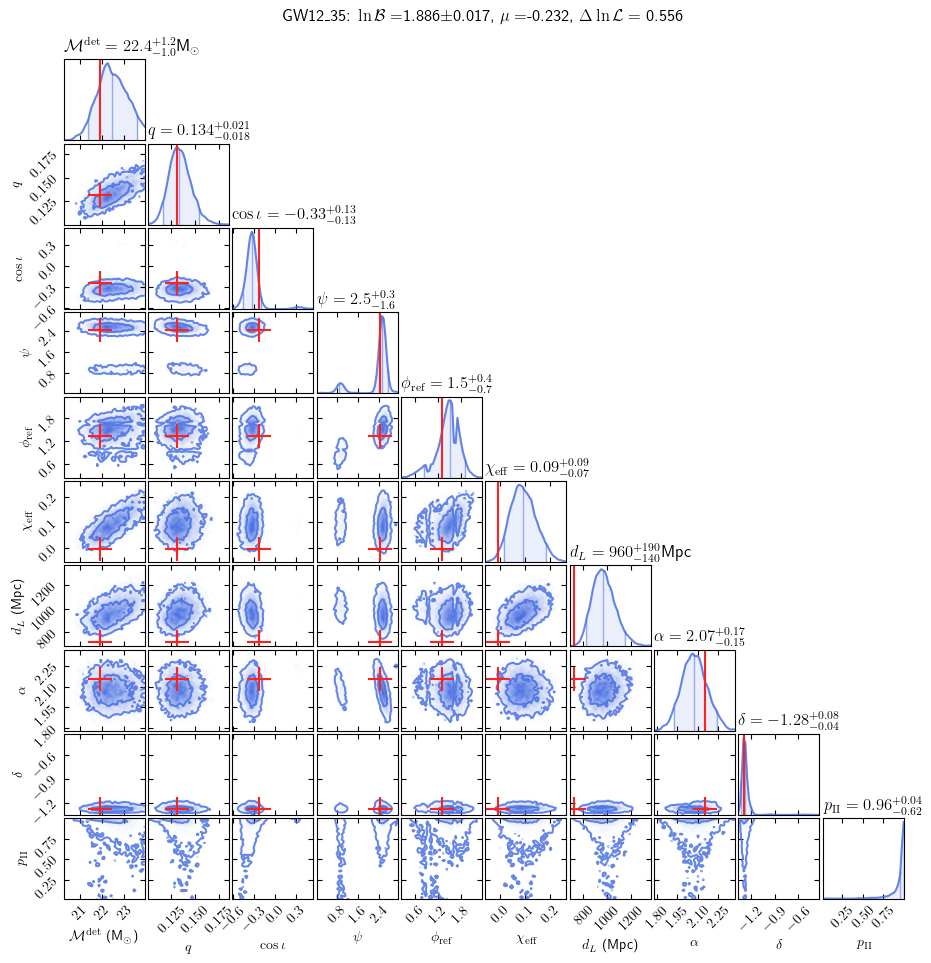

In [12]:
# pull up the corner plots for these
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))
for i in event_idx_outliers:
    # load this sample
    eventname = f'GW{seed}_{i}'
    eventdir = os.path.join(resdir, eventname)
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(eventdir, eventname)
    except FileNotFoundError:
        print(f"no samples found for {eventname}. continuing")
        continue
    samples['cosiota'] = np.cos(samples['iota'])
    pars_to_plot = [
        'mchirp', 'q', 'cosiota', 'psi', 'phi_ref', 'chieff', 'd_luminosity', 'ra', 'dec', 'p_lensed'
    ]
    try:
        cp = gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)
        cp.plot()
    except ValueError as e:  # if there's an issue plotting p_lensed, probably
        plt.close(cp.fig)
        print(f"ValueError: {e}. removing p_lensed and attempting to plot again...")
        pars_to_plot.remove('p_lensed')
        cp = gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)
        cp.plot()
    # injected parameters
    inj_par_dic = event_data.get_init_dict()['injection']['par_dic']
    helpers.add_derived_quantities_injection(inj_par_dic)
    inj_par_dic['cosiota'] = np.cos(inj_par_dic['iota'])
    inj_pars_to_plot = {k : v for k, v in inj_par_dic.items() if k in pars_to_plot}
    cp.scatter_points(inj_pars_to_plot, colors=['#FF2020'], s=300,
                                        zorder=2, marker='+', adjust_lims=True)
    # what lnB did we actually get?
    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    lnB = np.load(lnBayes_fn)
    # print(f"computed lnB = {med:.2f} ± {std:.2f}")
    lnB_str = 'NaN' if np.isnan(lnB[0]) else f'{lnB[0]:.3f}'r'$\pm$'f'{lnB[1]:.3f}'
    title_str = f'{eventname}: 'r'$\ln\mathcal B =$' + lnB_str + \
        r', $\mu = $'f'{mus[i]:.3f}, 'r'$\Delta\ln\mathcal L =$ 'f'{lnlike_mis[i]:.3f}'
    cp.fig.suptitle(title_str, y=0.97)

no samples found for GW12_0. continuing
loaded posterior samples for GW12_20 run 0
ValueError: Too many bins for data range. Cannot create 44 finite-sized bins.. removing p_lensed and attempting to plot again...
exception! signed integer is less than minimum continuing to next event.
loaded posterior samples for GW12_38 run 0
loaded posterior samples for GW12_52 run 0
loaded posterior samples for GW12_35 run 0


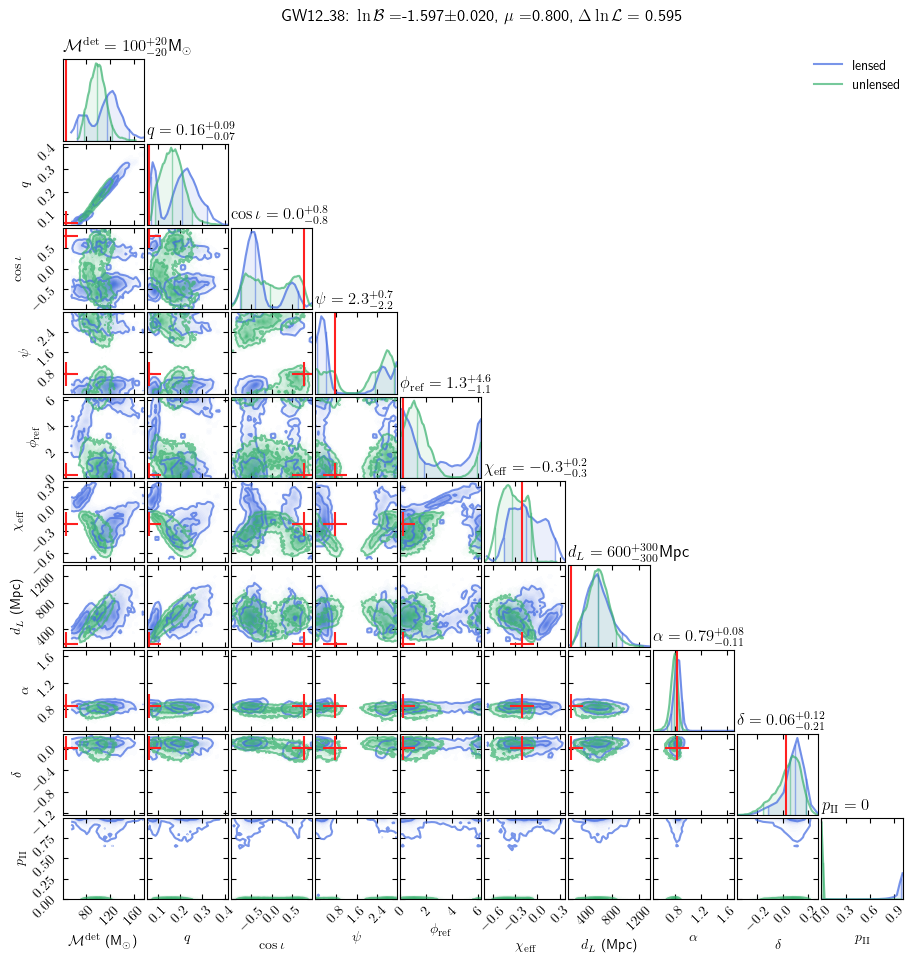

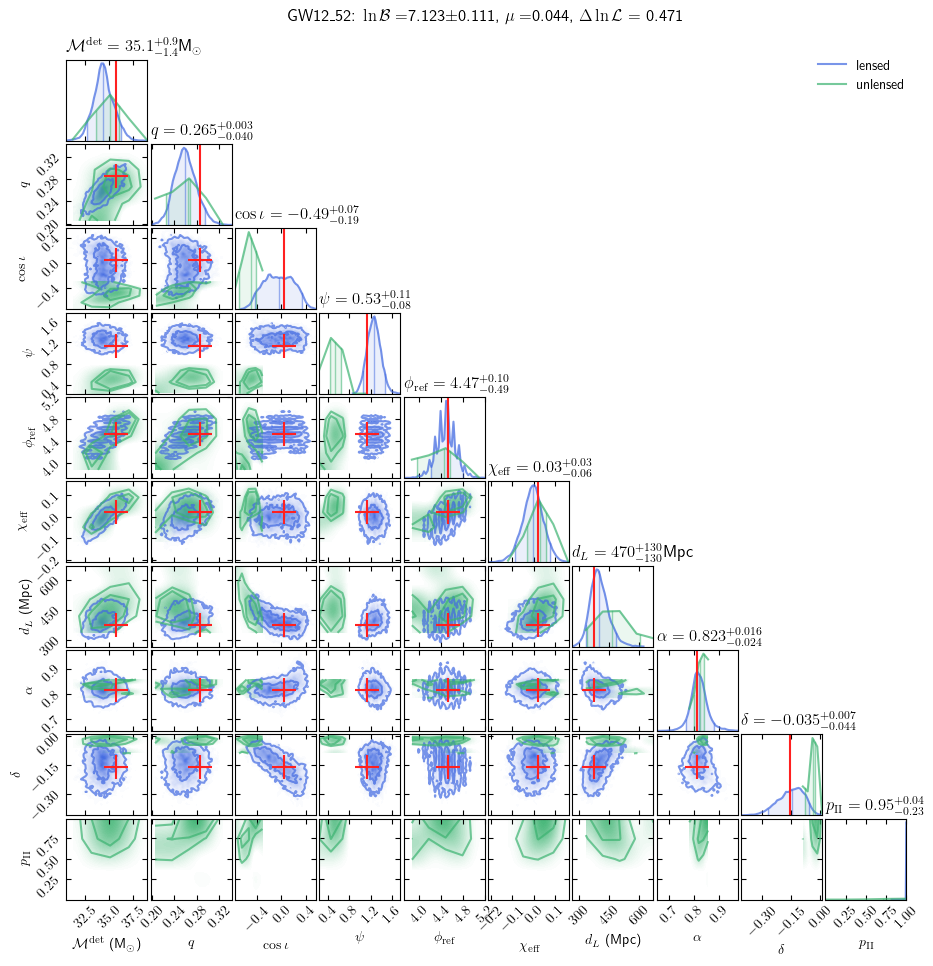

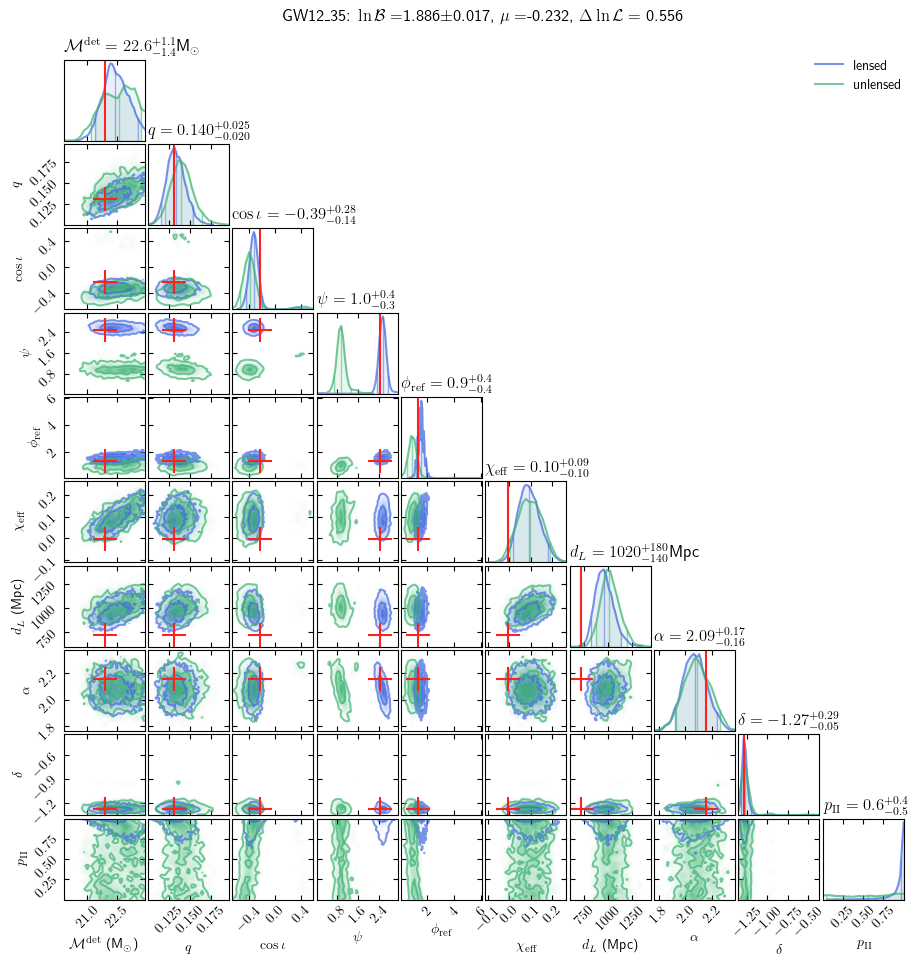

In [18]:
# pull up the corner plots for these
c1, c2 = 'royalblue', 'mediumseagreen'
plotstyles = [
        plotting.PlotStyle(color_2d=c1, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c1, alpha=0.7), tail_probability=1e-3),
        plotting.PlotStyle(color_2d=c2, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c2, alpha=0.7), tail_probability=1e-3)
]
for i in event_idx_outliers:
    # load this sample
    eventname = f'GW{seed}_{i}'
    eventdir = os.path.join(resdir, eventname)
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(eventdir, eventname)
    except FileNotFoundError:
        print(f"no samples found for {eventname}. continuing")
        continue
    samples['cosiota'] = np.cos(samples['iota'])
    lensed_idx = samples['lensed']
    pars_to_plot = [
        'mchirp', 'q', 'cosiota', 'psi', 'phi_ref', 'chieff', 'd_luminosity', 'ra', 'dec', 'p_lensed'
    ]
    try:
        cp = gw_plotting.MultiCornerPlot({'lensed' : samples[lensed_idx], 'unlensed' : samples[~lensed_idx]},
                                            params=pars_to_plot, plotstyles=plotstyles)
        cp.plot()
    except ValueError as e:  # if there's an issue plotting p_lensed, probably
        plt.close(cp.corner_plots[0].fig)
        print(f"ValueError: {e}. removing p_lensed and attempting to plot again...")
        pars_to_plot.remove('p_lensed')
        cp = gw_plotting.MultiCornerPlot({'lensed' : samples[lensed_idx], 'unlensed' : samples[~lensed_idx]},
                                            params=pars_to_plot, plotstyles=plotstyles)
        try:
            cp.plot()
        except Exception as e:
            plt.close(cp.corner_plots[0].fig)
            print(f"exception! {e} continuing to next event.")
            continue
    # injected parameters
    inj_par_dic = event_data.get_init_dict()['injection']['par_dic']
    helpers.add_derived_quantities_injection(inj_par_dic)
    inj_par_dic['cosiota'] = np.cos(inj_par_dic['iota'])
    inj_pars_to_plot = {k : v for k, v in inj_par_dic.items() if k in pars_to_plot}
    cp.scatter_points(inj_pars_to_plot, colors=['#FF2020'], s=300,
                                        zorder=2, marker='+', adjust_lims=True)
    # what lnB did we actually get?
    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    lnB = np.load(lnBayes_fn)
    # print(f"computed lnB = {med:.2f} ± {std:.2f}")
    lnB_str = 'NaN' if np.isnan(lnB[0]) else f'{lnB[0]:.3f}'r'$\pm$'f'{lnB[1]:.3f}'
    title_str = f'{eventname}: 'r'$\ln\mathcal B =$' + lnB_str + \
        r', $\mu = $'f'{mus[i]:.3f}, 'r'$\Delta\ln\mathcal L =$ 'f'{lnlike_mis[i]:.3f}'
    cp.corner_plots[0].fig.suptitle(title_str, y=0.97)

#### shape of the expected mismatch as a function of $\iota$

In [33]:
# let's grab the antenna response functions and SNR from this injection, then vary the inclination angle
iota_grid = np.arange(0., 0.501, 0.005) * np.pi
mu_grid = np.cos(iota_grid)
exp_mismatch_grid = np.array([
    helpers.expected_mismatch_with_HH(fplus, fcross, mu, HH) for mu in mu_grid
])
# compare to the old formula
old_exp_mismatch_grid = np.array([
    helpers.expected_mismatch(fplus, fcross, mu) for mu in mu_grid
])

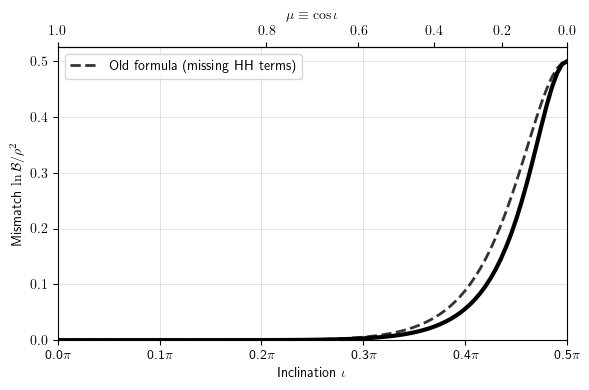

In [ ]:
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
xticks = np.arange(0., 0.51, 0.1) * np.pi
xticklabels = [f'{x / np.pi:.1f}'r'$\pi$' for x in xticks]
ax.plot(iota_grid, exp_mismatch_grid, c='k', lw=3, ls='-')
ax.plot(iota_grid, old_exp_mismatch_grid, c='k', lw=2, ls='--', alpha=0.8, label='Old formula (missing HH terms)')
ax.grid(alpha=0.5, lw=0.5)
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., None)
ax.set_xticks(xticks, labels=xticklabels)
ax.set_xlabel(r'Inclination $\iota$')
secax = ax.secondary_xaxis('top', functions=(lambda x: np.cos(x), lambda x: np.arccos(x)))
secax.set_xlabel(r'$\mu\equiv\cos\iota$')
ax.set_ylabel(r'Mismatch $\ln\mathcal B / \rho^2$')
ax.legend()